# 🧼 Project 4: Enterprise Data Quality Audit & Profiling Engine
**Business Domain:** Data Governance, Data Warehousing, & BI Engineering  
**Objective:** Audit a messy billing transaction log, profile columns for Completeness, Uniqueness, and Validity, map data anomalies, and export actionable Data Quality (DQ) scorecards.

### Business Context
The Data Warehousing team has been encountering frequent dashboard failures and aggregation errors. To prevent garbage-in, garbage-out analytics, we must build an automated quality check process that:
1. Audits dataset **completeness** (null rate metrics).
2. Profiles **uniqueness** of transaction keys (duplicate detection).
3. Validates formats (regex-style email verification, out-of-bounds metrics, and negative values).
4. Generates an easy-to-read Data Quality Scorecard for data engineers.

---

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

# Style config
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams.update({
    "font.size": 10,
    "figure.figsize": (8, 4.5),
    "axes.edgecolor": "#CBD5E1",
    "axes.facecolor": "#FAFAFA"
})

ACCENT = "#2563EB"
ACCENT_LIGHT = "#93C5FD"
ALERT = "#EA580C"
DARK = "#1E293B"
MUTED = "#64748B"


In [2]:
# Load raw billing data
df = pd.read_csv("billing_transactions_raw.csv")

print(f"Auditing Dataset Shape: {df.shape}")
df.head()

Auditing Dataset Shape: (1025, 7)


,transaction_id,customer_id,customer_email,transaction_date,transaction_amount,payment_method,billing_state
0,1000000,50328,customer_50328@gmail.com,2026-04-27,505.99,Credit Card,ZZ
1,1000001,50120,customer_50120@gmail.com,2026-05-29,660.25,Net Banking,MA
2,1000002,50446,NaN,2026-05-12,188.74,UPI,WA
3,1000003,50050,customer_50050@gmail.com,2026-04-18,1163.98,Net Banking,TX
4,1000004,50425,customer_50425@gmail.com,2026-04-16,328.40,UPI,MA


## 🔍 Part 1: Column-by-Column Data Quality Auditing
We evaluate three core dimensions of data quality:
1. **Completeness:** Percentage of non-missing (non-null/non-empty) records.
2. **Uniqueness:** Rate of unique values in the primary key field.
3. **Validity:** Percent of values conforming to business-defined validation rules.

In [3]:
total_rows = len(df)

# 1. Completeness Check
completeness = {}
for col in df.columns:
    nulls = df[col].isna() | (df[col] == "")
    completeness[col] = (total_rows - nulls.sum()) / total_rows

# 2. Uniqueness (Key constraints)
unique_tx = df['transaction_id'].nunique()
uniqueness = {col: 1.0 for col in df.columns}
uniqueness['transaction_id'] = unique_tx / total_rows

# 3. Validity Checks
validity = {}
validity["transaction_id"] = df["transaction_id"].apply(lambda x: str(x).isdigit() and len(str(x)) == 7).mean()
validity["customer_id"] = df["customer_id"].apply(lambda x: isinstance(x, (int, np.integer)) and x > 0).mean()

def validate_email(email):
    if not email: return True
    return "@" in str(email) and "." in str(email).split("@")[-1]
validity["customer_email"] = df["customer_email"].apply(lambda x: validate_email(x) if pd.notna(x) and x != "" else True).mean()

def validate_date(d):
    try:
        pd.to_datetime(d, format='%Y-%m-%d')
        return True
    except:
        return False
validity["transaction_date"] = df["transaction_date"].apply(validate_date).mean()

def validate_amount(a):
    if pd.isna(a): return True
    return a > 0 and a <= 10000.0
validity["transaction_amount"] = df["transaction_amount"].apply(validate_amount).mean()

valid_payment_methods = ["Credit Card", "Debit Card", "UPI", "Net Banking"]
validity["payment_method"] = df["payment_method"].apply(lambda x: x in valid_payment_methods if pd.notna(x) and x != "" else True).mean()

valid_states = ["NY", "CA", "TX", "WA", "FL", "IL", "MA"]
validity["billing_state"] = df["billing_state"].apply(lambda x: x in valid_states if pd.notna(x) and x != "" else True).mean()

# Consolidate DQ Scorecard
metrics = []
for col in df.columns:
    metrics.append({
        "Column": col,
        "Completeness": completeness[col],
        "Uniqueness": uniqueness[col],
        "Validity": validity[col]
    })
df_scorecard = pd.DataFrame(metrics)
df_scorecard

,Column,Completeness,Uniqueness,Validity
0,transaction_id,1.000000,0.97561,1.000000
1,customer_id,1.000000,1.00000,1.000000
2,customer_email,0.959024,1.00000,0.971707
3,transaction_date,1.000000,1.00000,1.000000
4,transaction_amount,0.975610,1.00000,0.974634
5,payment_method,1.000000,1.00000,0.927805
6,billing_state,0.988293,1.00000,0.984390


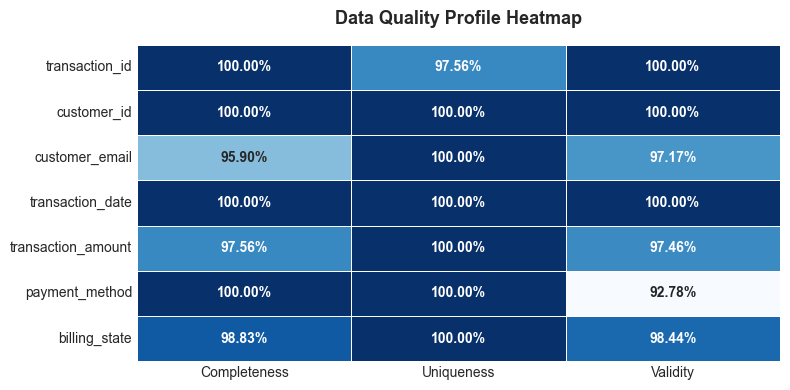

In [4]:
# Heatmap of Scorecard
plt.figure(figsize=(8, 4))
heatmap_data = df_scorecard.set_index("Column")[["Completeness", "Uniqueness", "Validity"]]
sns.heatmap(heatmap_data, annot=True, fmt=".2%", cmap="Blues", cbar=False, linewidths=.5, annot_kws={"weight": "bold"})
plt.title("Data Quality Profile Heatmap", fontsize=13, fontweight='bold', pad=15)
plt.ylabel("")
plt.tight_layout()
plt.show()

## ⚠️ Part 2: Outlier & Anomaly Breakdown
We profile anomaly metrics and count instances of nulls, duplicates, and bad formats.

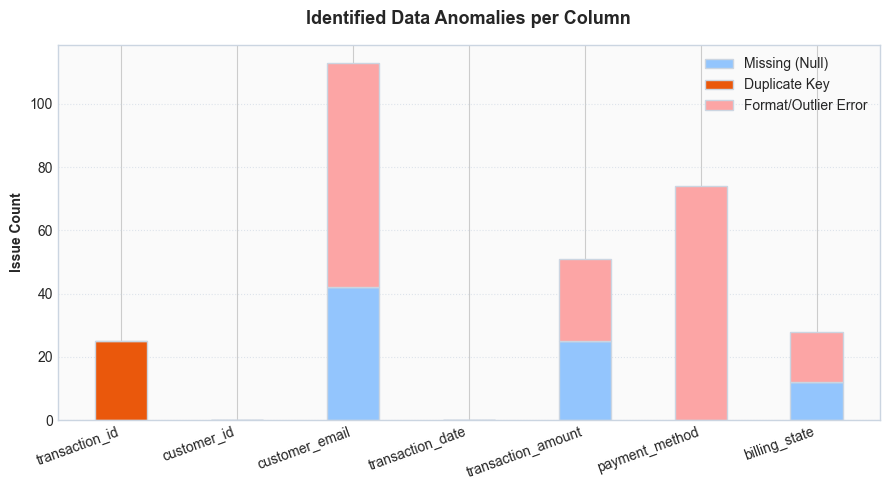

In [5]:
# Count null values
null_counts = df.apply(lambda x: (x.isna() | (x == "")).sum())
duplicate_rows = df.duplicated(subset=['transaction_id'], keep='first').sum()

# Count formatting anomalies
format_issues = {
    "transaction_id": 0,
    "customer_id": 0,
    "customer_email": df["customer_email"].apply(lambda x: 0 if validate_email(x) else 1).sum(),
    "transaction_date": df["transaction_date"].apply(lambda x: 0 if validate_date(x) else 1).sum(),
    "transaction_amount": df["transaction_amount"].apply(lambda x: 0 if validate_amount(x) else 1).sum(),
    "payment_method": df["payment_method"].apply(lambda x: 0 if (pd.isna(x) or x == "" or x in valid_payment_methods) else 1).sum(),
    "billing_state": df["billing_state"].apply(lambda x: 0 if (pd.isna(x) or x == "" or x in valid_states) else 1).sum()
}

# Stacked bar plot
plt.figure(figsize=(9, 5))
columns = df.columns
nulls_to_plot = [null_counts[col] for col in columns]
duplicates_to_plot = [duplicate_rows if col == "transaction_id" else 0 for col in columns]
format_to_plot = [format_issues[col] for col in columns]

ind = np.arange(len(columns))
width = 0.45

p1 = plt.bar(ind, nulls_to_plot, width, color='#93C5FD', edgecolor='#CBD5E1', label='Missing (Null)')
p2 = plt.bar(ind, duplicates_to_plot, width, bottom=nulls_to_plot, color='#EA580C', edgecolor='#CBD5E1', label='Duplicate Key')
bottom_3 = [n + d for n, d in zip(nulls_to_plot, duplicates_to_plot)]
p3 = plt.bar(ind, format_to_plot, width, bottom=bottom_3, color='#FCA5A5', edgecolor='#CBD5E1', label='Format/Outlier Error')

plt.ylabel('Issue Count', fontweight='bold')
plt.title('Identified Data Anomalies per Column', fontsize=13, fontweight='bold', pad=15)
plt.xticks(ind, columns, rotation=20, ha='right')
plt.legend(loc='upper right')
plt.grid(axis='y', linestyle=':', alpha=0.6, color='#CBD5E1')
plt.tight_layout()
plt.show()

## 💡 Part 3: Data Integrity Recommendations
Based on the audit report:
1. **Enforce Database Schema Constraints:** Set `transaction_id` as a `PRIMARY KEY` to resolve duplicate entries.
2. **Email Sanitation:** Enforce lowercase values and validation regex patterns upon user signup to fix malformed email records.
3. **Outlier Filtering:** Create an ETL staging gate that flags negative order amounts and orders exceeding \$10,000 to catch anomalies.
